# Cross-Domain Celebrity Retrieval — CLIP and ArcFace Fine Tuning
**Run cells top to bottom. Do not skip any cell.**

---
> ⚠️ First: **Runtime → Change runtime type → T4 GPU → Save**

**Exam day order**: `0 → 1 → 2 → 3 → 5 → 6 → 7 → 10 → 11`

| Cell | What it does | Required? |
| :--- | :--- | :--- |
| 0 | Install packages | ✅ Always |
| 1 | GPU check | ✅ Always |
| 2 | Mount Drive | ✅ Always |
| 3 | Imports | ✅ Always |
| 5 | Load CLIP + float32 | ✅ Always |
| A | Download Uzbek dataset | ✅ Always |
| 7 | Define all functions | ✅ Always |
| 8 | ArcFace head | ✅ Always |
| 9 | Fine-tuning on Uzbek | ✅ Always |
| B | Test accuracy + visualise | ✅ Always |
| 10 | Load checkpoint | 🔄 Only after session reset |
| 11 | Exam submission | ✅ Exam day |

## Cell 0 — Install Packages
Must run before everything else to avoid pandas conflicts.

In [1]:
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q datasets
print('Packages installed')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.2 MB/s eta 0:00:00
Packages installed


## Cell 1 — GPU Check

In [2]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU — go to Runtime → Change runtime type → T4 GPU')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## Cell 2 — Mount Google Drive
Saves model checkpoints so they survive session resets.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/celebrity_retrieval_final'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Checkpoints will be saved to: {SAVE_DIR}')

Mounted at /content/drive
Checkpoints will be saved to: /content/drive/MyDrive/celebrity_retrieval_final


## Cell 3 — Imports

In [4]:
import clip
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import math
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from collections import defaultdict

print('All imports OK')

All imports OK


## Cell 5 — Load CLIP ViT-L/14
Downloads ~900 MB weights on first run, cached after that.

In [5]:
print('Loading CLIP ViT-L/14...')
clip_model, clip_preprocess = clip.load('ViT-L/14', device=device)

# Convert to float32 — CLIP loads as float16 on GPU by default
# ArcFace overflows to NaN in float16
clip_model = clip_model.float()
clip_model.eval()

EMBED_DIM = clip_model.visual.output_dim
print(f'CLIP loaded on : {device}')
print(f'Embedding dim  : {EMBED_DIM}')  # 768 for ViT-L/14

Loading CLIP ViT-L/14...


100%|████████████████████████████████████████| 890M/890M [00:05<00:00, 165MiB/s]


CLIP loaded on : cuda
Embedding dim  : 768


#Download competition dataset:

In [6]:
pip install gdown

In [11]:
# train
!gdown 1gWtHBZvDWtDyFPnV8fMX789xO-ugqplL


Downloading...
From (original): https://drive.google.com/uc?id=1gWtHBZvDWtDyFPnV8fMX789xO-ugqplL
From (redirected): https://drive.google.com/uc?id=1gWtHBZvDWtDyFPnV8fMX789xO-ugqplL&confirm=t&uuid=dddba6e3-44a2-4894-ac14-63d96f99a195
To: /content/train.zip
100% 1.20G/1.20G [00:09<00:00, 131MB/s]


In [ ]:
!unzip /content/train.zip -d /content/competition

In [20]:
comp_train_dir='/content/train/train'

In [13]:
# test
!gdown 1gPdQoLsuaMIxobZreNpsJLEdsb9flsy7

Downloading...
From (original): https://drive.google.com/uc?id=1gPdQoLsuaMIxobZreNpsJLEdsb9flsy7
From (redirected): https://drive.google.com/uc?id=1gPdQoLsuaMIxobZreNpsJLEdsb9flsy7&confirm=t&uuid=cfd8712a-a3a2-40be-8dcf-a37f318683f5
To: /content/test.zip
100% 815M/815M [00:04<00:00, 163MB/s]


In [ ]:
!unzip '/content/test.zip' -d /content/competition

In [22]:
comp_test_dir='/content/competition/test'

## Cell 6 — Build train/val from Uzbek

In [31]:
imgs_dir='/content/competition'

In [44]:
# Build fine-tuning dataset from Uzbek instead of LFW
class UzbekIdentityDataset(Dataset):
    """Loads Uzbek faces grouped by identity for ArcFace training."""
    def __init__(self, root, preprocess, min_images=2):
        self.preprocess = preprocess
        label_to_paths  = defaultdict(list)

        for identity in os.listdir(root):
            folder = os.path.join(root, identity)
            if not os.path.isdir(folder):
                continue
            for img_file in os.listdir(folder):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    label_to_paths[identity].append(
                        os.path.join(folder, img_file))

        # Keep only identities with enough images
        kept            = {k: v for k, v in label_to_paths.items()
                           if len(v) >= min_images}
        self.label_map  = {name: idx for idx, name in enumerate(sorted(kept))}
        self.samples    = [(path, self.label_map[identity])
                           for identity, paths in kept.items()
                           for path in paths]
        self.num_classes = len(kept)
        print(f'UzbekDataset: {self.num_classes} identities, {len(self.samples)} images')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        return self.preprocess(img), label


# Build loaders — Cell A must run before this
uzbek_dataset = UzbekIdentityDataset(imgs_dir, clip_preprocess, min_images=2)
NUM_CLASSES   = uzbek_dataset.num_classes

n_train = int(0.8 * len(uzbek_dataset))
n_val   = len(uzbek_dataset) - n_train
train_ds, val_ds = torch.utils.data.random_split(
    uzbek_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

UzbekDataset: 250 identities, 5000 images
Train batches : 125
Val   batches : 16


# Build train/val & augmentation pipeline:

In [46]:
imgs_dir='/content/competition/train'

In [49]:
# Build fine-tuning dataset from LFW
class LFWIdentityDataset(Dataset):
    """Loads LFW faces grouped by identity for ArcFace training."""
    def __init__(self, root, preprocess, min_images=2):
        self.preprocess = preprocess
        label_to_paths  = defaultdict(list)
        for identity in os.listdir(root):
            folder = os.path.join(root, identity)
            if not os.path.isdir(folder):
                continue
            for img_file in os.listdir(folder):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    label_to_paths[identity].append(
                        os.path.join(folder, img_file))
        # Keep only identities with enough images
        kept            = {k: v for k, v in label_to_paths.items()
                           if len(v) >= min_images}
        self.label_map  = {name: idx for idx, name in enumerate(sorted(kept))}
        self.samples    = [(path, self.label_map[identity])
                           for identity, paths in kept.items()
                           for path in paths]
        self.num_classes = len(kept)
        print(f'LFWDataset: {self.num_classes} identities, {len(self.samples)} images')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        return self.preprocess(img), label

# Build loaders
# imgs_dir deve puntare alla cartella `train` (quella con le sottocartelle per persona)
imgs_dir = "/content/competition/train"   # <-- cambia con il tuo percorso

lfw_dataset  = LFWIdentityDataset(imgs_dir, clip_preprocess, min_images=2)
NUM_CLASSES  = lfw_dataset.num_classes

n_train = int(0.8 * len(lfw_dataset))
n_val   = len(lfw_dataset) - n_train
train_ds, val_ds = torch.utils.data.random_split(
    lfw_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

LFWDataset: 250 identities, 5000 images
Train batches : 125
Val   batches : 16


In [50]:
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, Subset
from collections import defaultdict
from PIL import Image
import os
import torch

# ── Augmentation pipeline ─────────────────────────────────────────────────────

strength = 'strong'
# 'potere' dell'augmentation, dipende dalla dimensione del dataset,
# eventualmente si possono cambiare i parametri
train_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.6, 1.0), ratio=(0.9, 1.1),
                        interpolation=T.InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.RandomApply([T.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.2, hue=0.08
    )], p=0.7),
    T.RandomGrayscale(p=0.15),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.3),
    T.ToTensor(),
    T.Normalize(mean=(0.48145466, 0.4578275,  0.40821073),
                std =(0.26862954, 0.26130258, 0.27577711)),
    T.RandomErasing(p=0.2, scale=(0.01, 0.08), ratio=(0.3, 3.3), value=0),
])

val_transform = T.Compose([
    T.Resize(224, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=(0.48145466, 0.4578275,  0.40821073),
                std =(0.26862954, 0.26130258, 0.27577711)),
])


# ── Dataset con transform separati per train e val ────────────────────────────
class UzbekIdentityDataset(Dataset):
    """Loads Uzbek faces grouped by identity for ArcFace training."""
    def __init__(self, root, preprocess, min_images=2):
        self.preprocess = preprocess
        label_to_paths  = defaultdict(list)

        for identity in os.listdir(root):
            folder = os.path.join(root, identity)
            if not os.path.isdir(folder):
                continue
            for img_file in os.listdir(folder):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    label_to_paths[identity].append(
                        os.path.join(folder, img_file))

        kept             = {k: v for k, v in label_to_paths.items()
                            if len(v) >= min_images}
        self.label_map   = {name: idx for idx, name in enumerate(sorted(kept))}
        self.samples     = [(path, self.label_map[identity])
                            for identity, paths in kept.items()
                            for path in paths]
        self.num_classes = len(kept)
        print(f'UzbekDataset: {self.num_classes} identities, {len(self.samples)} images')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        return self.preprocess(img), label


# ── Wrapper val subset: applica val_transform senza copiare il dataset ────────
class SubsetWithTransform(Subset):
    def __init__(self, subset, transform):
        super().__init__(subset.dataset, subset.indices)
        self.transform = transform

    def __getitem__(self, idx):
        path, label = self.dataset.samples[self.indices[idx]]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label


# ── Build dataset e loaders ───────────────────────────────────────────────────
# Train usa train_transform (con augmentation)
uzbek_dataset = UzbekIdentityDataset(imgs_dir, train_transform, min_images=2)
NUM_CLASSES   = uzbek_dataset.num_classes

n_train = int(0.8 * len(uzbek_dataset))
n_val   = len(uzbek_dataset) - n_train
train_subset, val_subset = torch.utils.data.random_split(
    uzbek_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

# Val usa val_transform (senza augmentation)
val_subset = SubsetWithTransform(val_subset, val_transform)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_subset,   batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train samples : {len(train_subset)}')
print(f'Val   samples : {len(val_subset)}')
print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

UzbekDataset: 250 identities, 5000 images
Train samples : 4000
Val   samples : 1000
Train batches : 125
Val   batches : 16


augmentation

## Cell 7 — Define all functions
Defines `extract_clip_embeddings`, `generate_submission`, and `visualise_retrieval`.
**Must run before Cell A/B and Cell 11.**

In [42]:
query_dir='/content/competition/test/query'
gallery_dir='/content/competition/test/gallery'

In [52]:
class FlatImageDataset(Dataset):
    """Loads images from a flat directory for CLIP embedding extraction."""
    def __init__(self, root_dir, preprocess):
        self.root_dir   = root_dir
        self.preprocess = preprocess
        self.image_paths = []
        self.image_names = []
        for filename in os.listdir(root_dir):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                self.image_paths.append(os.path.join(root_dir, filename))
                self.image_names.append(filename)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image    = Image.open(img_path).convert('RGB')
        return self.preprocess(image), self.image_names[idx]

def extract_clip_embeddings(folder_or_loader, model, preprocess=None,
                             batch_size=64, is_loader=False):
    """Extract L2-normalised CLIP embeddings from a folder or DataLoader."""
    model.eval()
    all_embs, all_meta = [], []

    loader = folder_or_loader if is_loader else DataLoader(
        FlatImageDataset(folder_or_loader, preprocess),
        batch_size=batch_size, num_workers=2, pin_memory=True
    )

    with torch.no_grad():
        for imgs, meta in loader:
            imgs = imgs.to(device)
            embs = model.encode_image(imgs).float()
            embs = embs / embs.norm(dim=-1, keepdim=True)
            all_embs.append(embs.cpu())
            all_meta.extend(meta if isinstance(meta[0], str) else meta.tolist())

    return torch.cat(all_embs), all_meta


def generate_submission(query_dir, gallery_dir, model, preprocess, top_k=10):
    """Full retrieval pipeline: embed → cosine similarity → rank → dict."""
    print('Extracting query embeddings...')
    q_embs, q_names = extract_clip_embeddings(query_dir, model, preprocess)
    print('Extracting gallery embeddings...')
    g_embs, g_names = extract_clip_embeddings(gallery_dir, model, preprocess)

    sim = torch.mm(q_embs, g_embs.t())

    res = {}
    for i, qname in enumerate(q_names):
        _, top_idx = torch.topk(sim[i], k=top_k)
        res[qname]  = [g_names[j] for j in top_idx.tolist()]
    return res


def visualise_retrieval(query_dir, gallery_dir, model, preprocess,
                         num_queries=3, top_k=5):
    """Shows query image + top-k retrieved gallery images side by side."""
    q_loader = DataLoader(FlatImageDataset(query_dir,   preprocess), batch_size=64)
    g_loader = DataLoader(FlatImageDataset(gallery_dir, preprocess), batch_size=64)

    q_embs, q_names = extract_clip_embeddings(q_loader, model, is_loader=True)
    g_embs, g_names = extract_clip_embeddings(g_loader, model, is_loader=True)

    sim      = torch.mm(q_embs, g_embs.t())
    q_sample = random.sample(range(len(q_names)), min(num_queries, len(q_names)))

    fig, axes = plt.subplots(len(q_sample), top_k + 1,
                              figsize=(3 * (top_k + 1), 3 * len(q_sample)))
    if len(q_sample) == 1:
        axes = [axes]

    for row, q_idx in enumerate(q_sample):
        _, top_idx = torch.topk(sim[q_idx], k=top_k)
        q_img = Image.open(os.path.join(query_dir, q_names[q_idx])).convert('RGB')
        axes[row][0].imshow(q_img)
        axes[row][0].set_title(f'QUERY\n{q_names[q_idx][:15]}', fontsize=8)
        axes[row][0].axis('off')
        for col, g_idx in enumerate(top_idx.tolist()):
            g_img = Image.open(os.path.join(gallery_dir, g_names[g_idx])).convert('RGB')
            score = sim[q_idx][g_idx].item()
            axes[row][col+1].imshow(g_img)
            axes[row][col+1].set_title(f'#{col+1} sim={score:.2f}\n{g_names[g_idx][:15]}', fontsize=7)
            axes[row][col+1].axis('off')

    plt.suptitle('Query → Top-K Retrieved Gallery Images', fontsize=12)
    plt.tight_layout()
    plt.show()


# ── Zero-shot validation on LFW val set (skipped if LFW not loaded) ──────────
if val_loader is not None:
    print('Running zero-shot evaluation on LFW val set...')
    val_embs, val_labels = extract_clip_embeddings(val_loader, clip_model, is_loader=True)
    sim_matrix = torch.mm(val_embs, val_embs.t())
    sim_matrix.fill_diagonal_(-1)
    top1_idx     = sim_matrix.argmax(dim=1)
    val_labels_t = torch.tensor(val_labels)
    top1_acc     = (val_labels_t[top1_idx] == val_labels_t).float().mean().item()
    print(f'Zero-shot Top-1 accuracy: {top1_acc * 100:.2f}%')

    print('LFW not loaded — skipping zero-shot LFW eval. Functions are ready.')

Running zero-shot evaluation on LFW val set...
Zero-shot Top-1 accuracy: 30.10%
LFW not loaded — skipping zero-shot LFW eval. Functions are ready.


## Cell 8 — ArcFace Head


In [55]:
if NUM_CLASSES is None:
    raise RuntimeError('NUM_CLASSES is None — run Cell 4 (LFW download) first.')

class ArcFaceHead(nn.Module):
    def __init__(self, embedding_dim, num_classes, s=30.0, m=0.3):
        super().__init__()
        self.s     = s
        self.m     = m
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th    = math.cos(math.pi - m)
        self.mm    = math.sin(math.pi - m) * m
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
        emb_norm    = F.normalize(embeddings, dim=1)
        weight_norm = F.normalize(self.weight, dim=1)
        cosine = F.linear(emb_norm, weight_norm)
        sine   = (1.0 - cosine.pow(2)).clamp(0).sqrt()
        phi    = cosine * self.cos_m - sine * self.sin_m
        phi    = torch.where(cosine > self.th, phi, cosine - self.mm)
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        return F.cross_entropy(output * self.s, labels.long())


arcface_head = ArcFaceHead(
    embedding_dim=EMBED_DIM,
    num_classes=NUM_CLASSES,
    s=30.0,
    m=0.3
).to(device)

print(f'ArcFace head: {EMBED_DIM} → {NUM_CLASSES} classes')
print(f'Trainable params: {sum(p.numel() for p in arcface_head.parameters()):,}')

ArcFace head: 768 → 250 classes
Trainable params: 192,000


#Fine-tuning

In [ ]:
if train_loader is None:
    raise RuntimeError('train_loader is None — run Cell A (Download Uzbek dataset) first.')

# Freeze all CLIP params
for param in clip_model.parameters():
    param.requires_grad = False

# Unfreeze last 2 transformer blocks + final LayerNorm + projection
for block in list(clip_model.visual.transformer.resblocks)[-2:]:
    for param in block.parameters():
        param.requires_grad = True
for param in clip_model.visual.ln_post.parameters():
    param.requires_grad = True
if hasattr(clip_model.visual, 'proj') and clip_model.visual.proj is not None:
    clip_model.visual.proj.requires_grad = True

trainable = sum(p.numel() for p in clip_model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in clip_model.parameters())
print(f'Trainable: {trainable:,} / {total_p:,} ({100*trainable/total_p:.1f}%)')

optimizer = torch.optim.AdamW([
    {'params': filter(lambda p: p.requires_grad, clip_model.parameters()), 'lr': 1e-5},
    {'params': arcface_head.parameters(), 'lr': 1e-4}
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)


def train_one_epoch(clip_model, arcface_head, loader, optimizer, device, epoch):
    clip_model.train()
    arcface_head.train()
    total_loss = 0.0

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs   = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()  # BEFORE forward pass

        embeddings = clip_model.encode_image(imgs).float()
        embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)

        if torch.isnan(embeddings).any():
            print(f'  WARNING: NaN embeddings at batch {batch_idx}, skipping.')
            continue

        loss = arcface_head(embeddings, labels)

        if torch.isnan(loss):
            print(f'  WARNING: NaN loss at batch {batch_idx}, skipping.')
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(clip_model.parameters()) + list(arcface_head.parameters()), 1.0)
        optimizer.step()
        total_loss += loss.item()

        if (batch_idx + 1) % 20 == 0:
            print(f'  Epoch {epoch} | Batch {batch_idx+1}/{len(loader)} | Loss: {loss.item():.4f}')

    return total_loss / len(loader)


def evaluate_retrieval(clip_model, loader, device):
    embs, labels = extract_clip_embeddings(loader, clip_model, is_loader=True)
    sim = torch.mm(embs, embs.t())
    sim.fill_diagonal_(-1)
    labels_t      = torch.tensor(labels)
    top1_acc      = (labels_t[sim.argmax(dim=1)] == labels_t).float().mean().item()
    top10_correct = (labels_t[sim.topk(10, dim=1).indices] == labels_t.unsqueeze(1)).any(dim=1)
    top10_acc     = top10_correct.float().mean().item()
    return top1_acc, top10_acc


EPOCHS    = 3
best_top1 = 0.0

print('Starting fine-tuning...\n')
for epoch in range(1, EPOCHS + 1):
    avg_loss = train_one_epoch(clip_model, arcface_head, train_loader, optimizer, device, epoch)
    scheduler.step()
    top1, top10 = evaluate_retrieval(clip_model, val_loader, device)
    print(f'Epoch {epoch}/{EPOCHS} | Loss: {avg_loss:.4f} | Top-1: {top1*100:.2f}% | Top-10: {top10*100:.2f}%')

    if top1 > best_top1:
        best_top1 = top1
        torch.save({
            'epoch'      : epoch,
            'clip_state' : clip_model.state_dict(),
            'head_state' : arcface_head.state_dict(),
            'top1'       : top1
        }, f'{SAVE_DIR}/best_model.pth')
        print(f'   New best saved (Top-1={top1*100:.2f}%)')

print(f'\nTraining complete. Best Top-1: {best_top1*100:.2f}%')

Trainable: 25,980,928 / 427,616,513 (6.1%)
Starting fine-tuning...



/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  Epoch 1 | Batch 20/125 | Loss: 14.5464


# For logging on WandB:

In [37]:
!pip install wandb -qU
import wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.3/27.3 MB 77.2 MB/s eta 0:00:00


In [38]:
# la mia wandb_key è

# andrebbe settata come segreto su colab e poi fare in modo che il notebook abbia l'accesso

from google.colab import userdata
wandb_key=userdata.get('WANDB_KEY')
wandb.login(wandb_key)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: margh3 (margh3-unitn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [39]:
# ── Init wandb ────────────────────────────────────────────────────────────────
wandb.init(
    project = "cliparcface-face-retrieval",
    name    = f"arcface-finetuning",
    config  = {
        # Modello
        "clip_model"             : "ViT-L/14",
        "embedding_dim"          : EMBED_DIM,
        "num_classes"            : NUM_CLASSES,
        # ArcFace
        "arcface_s"              : arcface_head.s,
        "arcface_m"              : arcface_head.m,
        # Training
        "epochs"                 : EPOCHS,
        "backbone_lr"            : 1e-5,
        "head_lr"                : 1e-4,
        "weight_decay"           : 1e-4,
        # "scheduler"              : "CosineAnnealingLR",
        # "scheduler_eta_min"      : 1e-6,
        "unfreeze_last_n_blocks" : 2,
        "grad_clip_norm"         : 1.0,
        # Dataset
        "dataset"                : "competition",
        "train_samples"          : len(train_loader.dataset),
        "val_samples"            : len(val_loader.dataset),
        "train_batches"          : len(train_loader),
        "batch_size_train"       : train_loader.batch_size,
        "batch_size_val"         : val_loader.batch_size,
        "augmentation_strength"  : strength,  # data augmentation strength
    }
)

if train_loader is None:
    raise RuntimeError('train_loader is None — run Cell A (Download Uzbek dataset) first.')

# Freeze all CLIP params
for param in clip_model.parameters():
    param.requires_grad = False

# Unfreeze last 2 transformer blocks + final LayerNorm + projection
for block in list(clip_model.visual.transformer.resblocks)[-2:]:
    for param in block.parameters():
        param.requires_grad = True
for param in clip_model.visual.ln_post.parameters():
    param.requires_grad = True
if hasattr(clip_model.visual, 'proj') and clip_model.visual.proj is not None:
    clip_model.visual.proj.requires_grad = True

trainable = sum(p.numel() for p in clip_model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in clip_model.parameters())
print(f'Trainable: {trainable:,} / {total_p:,} ({100*trainable/total_p:.1f}%)')

wandb.config.update({
    "trainable_params" : trainable,
    "total_params"     : total_p,
    "trainable_pct"    : round(100 * trainable / total_p, 2),
})

optimizer = torch.optim.AdamW([
    {'params': filter(lambda p: p.requires_grad, clip_model.parameters()), 'lr': 1e-5},
    {'params': arcface_head.parameters(), 'lr': 1e-4}
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)


def train_one_epoch(clip_model, arcface_head, loader, optimizer, device, epoch):
    clip_model.train()
    arcface_head.train()
    total_loss  = 0.0
    batch_losses = []

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs   = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        embeddings = clip_model.encode_image(imgs).float()
        embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)

        if torch.isnan(embeddings).any():
            print(f'  WARNING: NaN embeddings at batch {batch_idx}, skipping.')
            continue

        loss = arcface_head(embeddings, labels)

        if torch.isnan(loss):
            print(f'  WARNING: NaN loss at batch {batch_idx}, skipping.')
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(clip_model.parameters()) + list(arcface_head.parameters()), 1.0)
        optimizer.step()

        loss_val = loss.item()
        total_loss   += loss_val
        batch_losses.append(loss_val)

        # Log ogni batch
        wandb.log({
            "batch/loss"  : loss_val,
            "batch/epoch" : epoch,
            "batch/step"  : (epoch - 1) * len(loader) + batch_idx,
        })

        if (batch_idx + 1) % 20 == 0:
            print(f'  Epoch {epoch} | Batch {batch_idx+1}/{len(loader)} | Loss: {loss_val:.4f}')

    return total_loss / len(loader)


def evaluate_retrieval(clip_model, loader, device):
    embs, labels = extract_clip_embeddings(loader, clip_model, is_loader=True)
    sim = torch.mm(embs, embs.t())
    sim.fill_diagonal_(-1)
    labels_t      = torch.tensor(labels)
    top1_acc      = (labels_t[sim.argmax(dim=1)] == labels_t).float().mean().item()
    top10_correct = (labels_t[sim.topk(10, dim=1).indices] == labels_t.unsqueeze(1)).any(dim=1)
    top10_acc     = top10_correct.float().mean().item()
    return top1_acc, top10_acc


EPOCHS    = 3
best_top1 = 0.0

print('Starting fine-tuning...\n')
for epoch in range(1, EPOCHS + 1):
    avg_loss = train_one_epoch(clip_model, arcface_head, train_loader, optimizer, device, epoch)
    scheduler.step()
    top1, top10 = evaluate_retrieval(clip_model, val_loader, device)

    current_lr_backbone = optimizer.param_groups[0]['lr']
    current_lr_head     = optimizer.param_groups[1]['lr']

    print(f'Epoch {epoch}/{EPOCHS} | Loss: {avg_loss:.4f} | Top-1: {top1*100:.2f}% | Top-10: {top10*100:.2f}%')

    # Log per epoch
    wandb.log({
        "epoch"              : epoch,
        "epoch/loss"         : avg_loss,
        "epoch/top1_acc"     : top1,
        "epoch/top10_acc"    : top10,
        # "epoch/lr_backbone"  : current_lr_backbone,
        # "epoch/lr_head"      : current_lr_head,
    })

    if top1 > best_top1:
        best_top1 = top1
        ckpt_path = f'{SAVE_DIR}/best_model.pth'
        torch.save({
            'epoch'      : epoch,
            'clip_state' : clip_model.state_dict(),
            'head_state' : arcface_head.state_dict(),
            'top1'       : top1
        }, ckpt_path)
        print(f'   New best saved (Top-1={top1*100:.2f}%)')

        # Salva il checkpoint anche su wandb
        wandb.save(ckpt_path)
        wandb.run.summary["best_top1"]       = best_top1
        wandb.run.summary["best_top10"]      = top10
        wandb.run.summary["best_epoch"]      = epoch

print(f'\nTraining complete. Best Top-1: {best_top1*100:.2f}%')
wandb.run.summary["final_loss"] = avg_loss
wandb.finish()

NameError: name 'EPOCHS' is not defined

## Cell B — Test accuracy + visualise

Splits dataset into query/gallery, runs retrieval, prints accuracy, and visualises results.

Run once for zero-shot score, then again after fine-tuning (Cells 8-9) to compare.

In [ ]:
QUERY_DIR_TEST   = '/content/uzbek_query'
GALLERY_DIR_TEST = '/content/uzbek_gallery'
os.makedirs(QUERY_DIR_TEST,   exist_ok=True)
os.makedirs(GALLERY_DIR_TEST, exist_ok=True)

for f in os.listdir(QUERY_DIR_TEST):   os.remove(os.path.join(QUERY_DIR_TEST, f))
for f in os.listdir(GALLERY_DIR_TEST): os.remove(os.path.join(GALLERY_DIR_TEST, f))

SOURCE          = "uzbek_multimodal"
NATURAL_DOMAIN  = 'photo'      # dominio naturale → query
SYNTHETIC_DOMAINS = {           # domini sintetici → gallery
    'sketch', 'cartoon', 'painting', 'infrared', 'low_light'
}

for identity in os.listdir(SOURCE):
    identity_folder = os.path.join(SOURCE, identity)
    if not os.path.isdir(identity_folder):
        continue

    files = os.listdir(identity_folder)

    # Query: tutte le foto naturali (photo_0.jpg, photo_1.jpg, ...)
    natural = [f for f in files if os.path.splitext(f)[0].rsplit('_', 1)[0] == NATURAL_DOMAIN]
    for fname in natural:
        shutil.copy(
            os.path.join(identity_folder, fname),
            os.path.join(QUERY_DIR_TEST, f'{identity}_{fname}')
        )

    # Gallery: tutti i domini sintetici
    synthetic = [
        f for f in files
        if os.path.splitext(f)[0].rsplit('_', 1)[0] in SYNTHETIC_DOMAINS
    ]
    for fname in synthetic:
        shutil.copy(
            os.path.join(identity_folder, fname),
            os.path.join(GALLERY_DIR_TEST, f'{identity}_{fname}')
        )

print(f'Query   : {len(os.listdir(QUERY_DIR_TEST))} images  (solo {NATURAL_DOMAIN})')
print(f'Gallery : {len(os.listdir(GALLERY_DIR_TEST))} images (domini sintetici)')

# ── Retrieval ─────────────────────────────────────────────────────────────────
clip_model.eval()
submission = generate_submission(
    QUERY_DIR_TEST, GALLERY_DIR_TEST,
    model=clip_model, preprocess=clip_preprocess, top_k=10
)

# ── Valutazione accuracy ──────────────────────────────────────────────────────
correct_top1  = 0
correct_top10 = 0

for query_filename, retrieved_list in submission.items():
    # L'identità è tutto prima del primo '_' che precede il dominio
    # es. 'abbos_fayzullayev_photo_0.jpg' → 'abbos_fayzullayev'
    query_identity = '_'.join(query_filename.split('_')[:-2])
    top1_identity  = '_'.join(retrieved_list[0].split('_')[:-2])

    if top1_identity == query_identity:
        correct_top1 += 1

    retrieved_ids = ['_'.join(r.split('_')[:-2]) for r in retrieved_list]
    if query_identity in retrieved_ids:
        correct_top10 += 1

total = len(submission)
print(f'\nTop-1  accuracy : {correct_top1  / total * 100:.2f}%')
print(f'Top-10 accuracy : {correct_top10 / total * 100:.2f}%')

# ── Visualizzazione ───────────────────────────────────────────────────────────
visualise_retrieval(
    QUERY_DIR_TEST, GALLERY_DIR_TEST,
    clip_model, clip_preprocess,
    num_queries=3, top_k=10,
)

Taking a single random picture for identity as a query:

Query   : 32 images  (1 foto naturale casuale per identità)
Gallery : 3352 images (foto naturali restanti + sintetici)
Extracting query embeddings...
Extracting gallery embeddings...

Top-1  accuracy : 90.62%
Top-10 accuracy : 100.00%


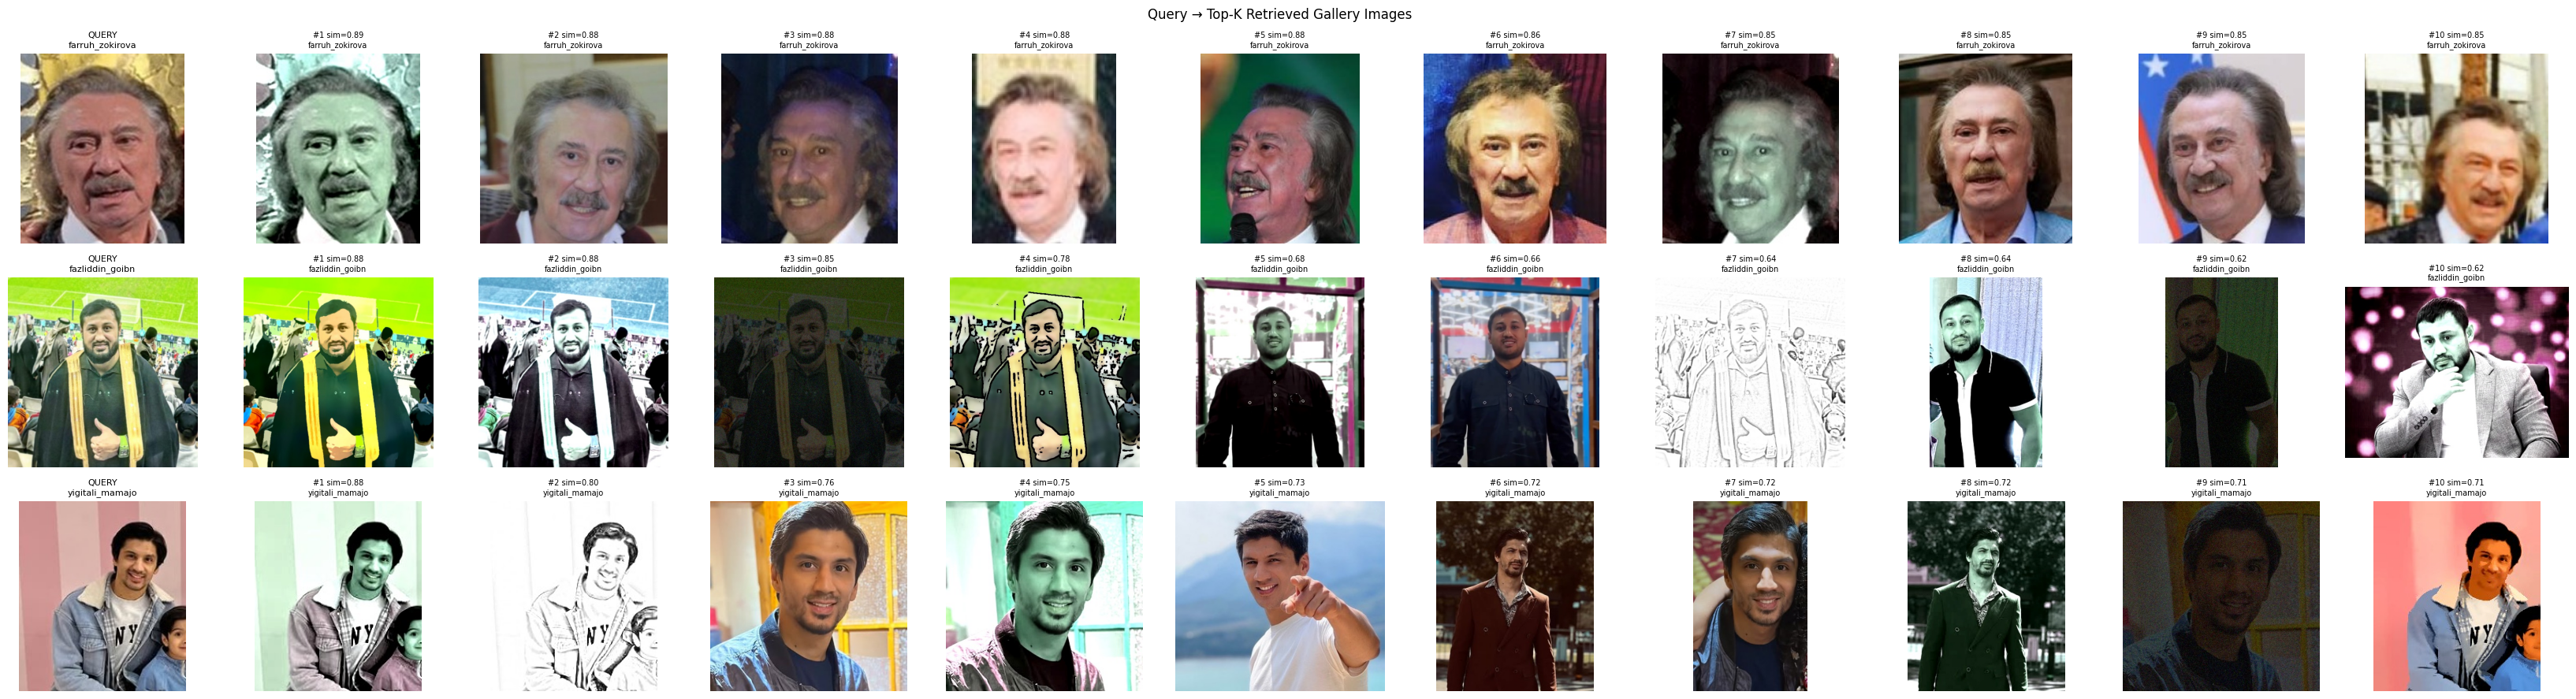

In [ ]:
import random

QUERY_DIR_TEST   = '/content/uzbek_query'
GALLERY_DIR_TEST = '/content/uzbek_gallery'
os.makedirs(QUERY_DIR_TEST,   exist_ok=True)
os.makedirs(GALLERY_DIR_TEST, exist_ok=True)

for f in os.listdir(QUERY_DIR_TEST):   os.remove(os.path.join(QUERY_DIR_TEST, f))
for f in os.listdir(GALLERY_DIR_TEST): os.remove(os.path.join(GALLERY_DIR_TEST, f))

SOURCE            = "uzbek_multimodal"
NATURAL_DOMAIN    = 'photo'
SYNTHETIC_DOMAINS = {'sketch', 'cartoon', 'painting', 'infrared', 'low_light'}

# Nessun seed fisso → queries diverse ad ogni esecuzione
for identity in os.listdir(SOURCE):
    identity_folder = os.path.join(SOURCE, identity)
    if not os.path.isdir(identity_folder):
        continue

    files   = os.listdir(identity_folder)
    natural = [f for f in files
               if os.path.splitext(f)[0].rsplit('_', 1)[0] == NATURAL_DOMAIN]

    if not natural:
        continue

    # Sceglie UNA foto naturale casuale come query
    query_fname = random.choice(natural)
    shutil.copy(
        os.path.join(identity_folder, query_fname),
        os.path.join(QUERY_DIR_TEST, f'{identity}_{query_fname}')
    )

    # Le altre foto naturali + tutti i sintetici → gallery
    for fname in natural:
        if fname == query_fname:
            continue
        shutil.copy(
            os.path.join(identity_folder, fname),
            os.path.join(GALLERY_DIR_TEST, f'{identity}_{fname}')
        )

    synthetic = [f for f in files
                 if os.path.splitext(f)[0].rsplit('_', 1)[0] in SYNTHETIC_DOMAINS]
    for fname in synthetic:
        shutil.copy(
            os.path.join(identity_folder, fname),
            os.path.join(GALLERY_DIR_TEST, f'{identity}_{fname}')
        )

print(f'Query   : {len(os.listdir(QUERY_DIR_TEST))} images  (1 foto naturale casuale per identità)')
print(f'Gallery : {len(os.listdir(GALLERY_DIR_TEST))} images (foto naturali restanti + sintetici)')

# ── Retrieval ─────────────────────────────────────────────────────────────────
clip_model.eval()
submission = generate_submission(
    QUERY_DIR_TEST, GALLERY_DIR_TEST,
    model=clip_model, preprocess=clip_preprocess, top_k=10
)

# ── Valutazione accuracy ──────────────────────────────────────────────────────
correct_top1  = 0
correct_top10 = 0

for query_filename, retrieved_list in submission.items():
    query_identity = '_'.join(query_filename.split('_')[:-2])
    top1_identity  = '_'.join(retrieved_list[0].split('_')[:-2])

    if top1_identity == query_identity:
        correct_top1 += 1

    retrieved_ids = ['_'.join(r.split('_')[:-2]) for r in retrieved_list]
    if query_identity in retrieved_ids:
        correct_top10 += 1

total = len(submission)
print(f'\nTop-1  accuracy : {correct_top1  / total * 100:.2f}%')
print(f'Top-10 accuracy : {correct_top10 / total * 100:.2f}%')

# ── Visualizzazione ───────────────────────────────────────────────────────────
visualise_retrieval(
    QUERY_DIR_TEST, GALLERY_DIR_TEST,
    clip_model, clip_preprocess,
    num_queries=3, top_k=10,
)

Query   : 32 images
Gallery : 3352 images
Extracting query embeddings...
Extracting gallery embeddings...

Top-1  accuracy : 12.50%
Top-10 accuracy : 93.75%


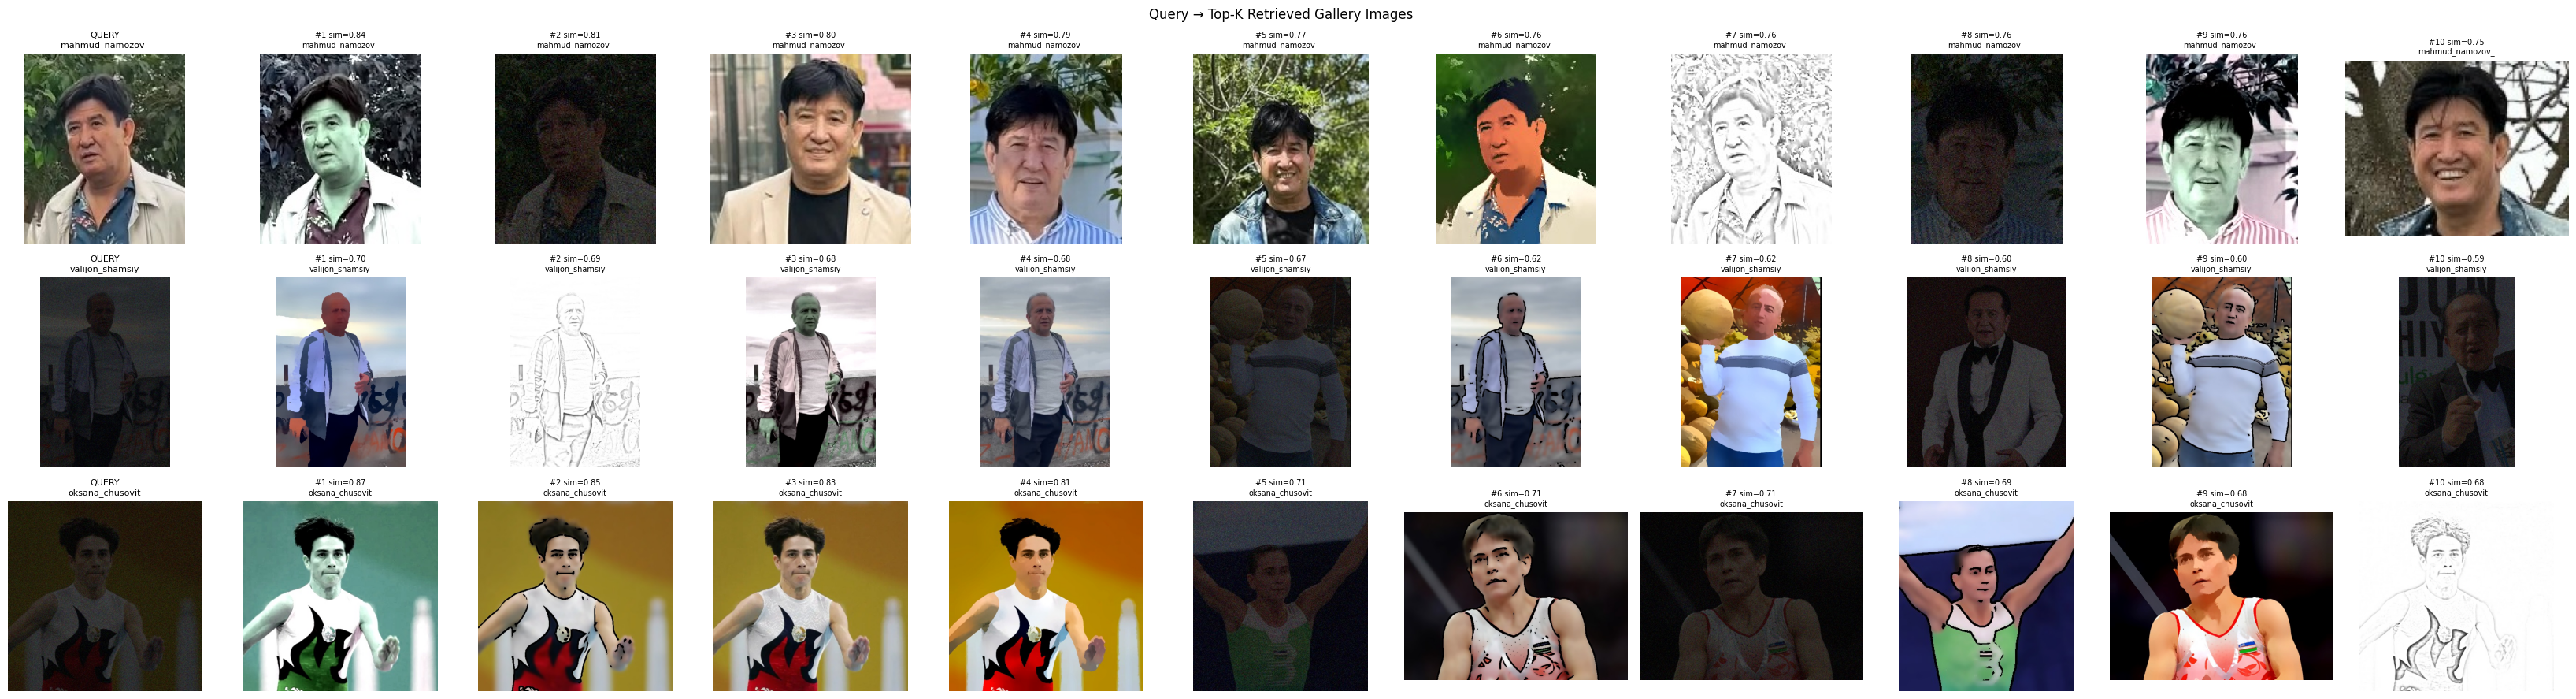

In [ ]:
# query and gallery are from mixed domains

# QUERY_DIR_TEST   = '/content/uzbek_query'
# GALLERY_DIR_TEST = '/content/uzbek_gallery'
# os.makedirs(QUERY_DIR_TEST,   exist_ok=True)
# os.makedirs(GALLERY_DIR_TEST, exist_ok=True)

# # Clear previous run
# for f in os.listdir(QUERY_DIR_TEST):   os.remove(os.path.join(QUERY_DIR_TEST, f))
# for f in os.listdir(GALLERY_DIR_TEST): os.remove(os.path.join(GALLERY_DIR_TEST, f))

# # Split: 1 image per identity → query, rest → gallery
# SOURCE = imgs_dir
# for identity in os.listdir(SOURCE):
#     identity_folder = os.path.join(SOURCE, identity)
#     images = os.listdir(identity_folder)
#     if len(images) < 2:
#         continue
#     random.shuffle(images)
#     shutil.copy(
#         os.path.join(identity_folder, images[0]),
#         os.path.join(QUERY_DIR_TEST, f'{identity}_{images[0]}')
#     )
#     for img in images[1:]:
#         shutil.copy(
#             os.path.join(identity_folder, img),
#             os.path.join(GALLERY_DIR_TEST, f'{identity}_{img}')
#         )

# print(f'Query   : {len(os.listdir(QUERY_DIR_TEST))} images')
# print(f'Gallery : {len(os.listdir(GALLERY_DIR_TEST))} images')

# # Run retrieval
# clip_model.eval()
# submission = generate_submission(
#     QUERY_DIR_TEST, GALLERY_DIR_TEST,
#     model=clip_model, preprocess=clip_preprocess, top_k=10
# )

# # Evaluate accuracy
# correct_top1 = 0
# correct_top10 = 0
# for query_filename, retrieved_list in submission.items():
#     query_identity    = '_'.join(query_filename.split('_')[:-1])
#     top1_identity     = '_'.join(retrieved_list[0].split('_')[:-1])
#     if top1_identity == query_identity:
#         correct_top1 += 1
#     retrieved_ids = ['_'.join(r.split('_')[:-1]) for r in retrieved_list]
#     if query_identity in retrieved_ids:
#         correct_top10 += 1

# total = len(submission)
# print(f'\nTop-1  accuracy : {correct_top1  / total * 100:.2f}%')
# print(f'Top-10 accuracy : {correct_top10 / total * 100:.2f}%')

# # Visualise 3 random queries
# visualise_retrieval(QUERY_DIR_TEST, GALLERY_DIR_TEST,
#                     clip_model, clip_preprocess,
#                     num_queries=3, top_k=10)

## Cell 10 — Load Best Checkpoint
⚠️ Only run this after a **session reset**.
If you just finished Cell 9 in the same session, skip this and go to Cell 11.

In [ ]:
CKPT_PATH = f'{SAVE_DIR}/best_model.pth'
try:
    ckpt = torch.load(CKPT_PATH, map_location=device)
    clip_model.load_state_dict(ckpt['clip_state'])
    clip_model.eval()
    print(f'Loaded checkpoint from epoch {ckpt["epoch"]} (Top-1 = {ckpt["top1"]*100:.2f}%)')
except RuntimeError as e:
    print(f"ERROR loading checkpoint: {e}")
    print("\nThis usually means the 'best_model.pth' file is corrupted or incomplete.")
    print("Reminder from the notebook:")
    print("⚠️ Only run this after a **session reset**. If you just finished Cell 9 in the same session, skip this and go to Cell 11.")
    print("\nIf you *did* reset your session and still get this error, please re-run Cell 9 to re-generate the checkpoint.")

ERROR loading checkpoint: PytorchStreamReader failed reading file .format_version: invalid header or archive is corrupted

This usually means the 'best_model.pth' file is corrupted or incomplete.
Reminder from the notebook:
⚠️ Only run this after a **session reset**. If you just finished Cell 9 in the same session, skip this and go to Cell 11.

If you *did* reset your session and still get this error, please re-run Cell 9 to re-generate the checkpoint.


## Cell 11 — Generate Exam Submission
Update `QUERY_DIR` and `GALLERY_DIR` with the paths given on exam day.

In [ ]:
# Step 1: find your exam folders (run this first to see the paths)
!find /content -type d -name 'query'   2>/dev/null
!find /content -type d -name 'gallery' 2>/dev/null

In [26]:
# Step 2: update these paths and run
QUERY_DIR   = '/content/test/query'    # <-- update on exam day
GALLERY_DIR = '/content/test/gallery'  # <-- update on exam day

clip_model.eval()
submission = generate_submission(
    QUERY_DIR, GALLERY_DIR,
    model=clip_model,
    preprocess=clip_preprocess,
    top_k=10
)

print(f'Submission ready: {len(submission)} queries')
print(f'Example: {list(submission.items())[0]}')

# Uncomment to submit:
# submit(submission, 'Your Group Name')

NameError: name 'generate_submission' is not defined